# 11 — Tu viaje matutino: minutos perdidos

**ENAI 603 · WMATA Delay Project · Lente E (Pasajero)**

Reformulamos los hallazgos de los cuadernos anteriores en términos humanos.

Pregunta: *si vivís en un suburbio del DC metro y tomás el metro en la mañana entre semana, ¿qué tan confiable es tu trayecto, y cuántos minutos en total pierde la población de pasajeros como consecuencia?*

Definimos cinco rutas representativas (origen → destino) que cubren las principales líneas radiales hacia el centro de DC, y para cada una calculamos:

- **Confiabilidad**: % de viajes (filas de predicción) etiquetados como retrasados.
- **Peor día** del período observado.
- **Retraso promedio** cuando hay retraso (en minutos).

Al final, estimamos el **total de minutos perdidos** por todos los pasajeros del sistema en las 5 semanas observadas, usando un proxy de carga por tren.

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Cargar datos y definir rutas

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at", "date"], usecols=[
    "collected_at", "date", "line", "location_code", "location_name",
    "destination_name", "is_delayed", "is_orphan",
    "hour", "day_of_week", "is_weekend", "minutes_num",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df[df["is_orphan"] == 0].copy()

# Conexión a stations para verificar códigos
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
stations = pd.read_sql("SELECT station_code, station_name FROM stations", conn)
conn.close()
print(f"Total filas: {len(df):,}")
print(f"\nMuestra de estaciones disponibles:")
print(stations.head(10).to_string(index=False))

Total filas: 9,215,922

Muestra de estaciones disponibles:
station_code                  station_name
         A01                  Metro Center
         A02                Farragut North
         A03                 Dupont Circle
         A04 Woodley Park-Zoo/Adams Morgan
         A05                Cleveland Park
         A06                  Van Ness-UDC
         A07                 Tenleytown-AU
         A08            Friendship Heights
         A09                      Bethesda
         A10                Medical Center


In [3]:
# Cinco trayectos matutinos representativos.
# Importante: NO usamos terminales como origen porque después del filtro
# is_orphan==0 los terminales se quedan vacíos (un tren al final de la
# línea no tiene "próxima llegada" que detectar dentro de 15 min).
# Usamos estaciones intermedias en cada línea, con destination = el extremo
# de la línea EN DIRECCIÓN AL CENTRO para representar AM commute eastbound.
COMMUTES = [
    {"name": "Forest Glen → Metro Center",      "line": "RD", "origin": "B09", "dest_keyword": "Shady"},
    {"name": "Dunn Loring → Downtown",          "line": "OR", "origin": "K07", "dest_keyword": "Carrollton"},
    {"name": "Van Dorn → L'Enfant Plaza",       "line": "BL", "origin": "J02", "dest_keyword": "Largo"},
    {"name": "Suitland → L'Enfant Plaza",       "line": "GR", "origin": "F10", "dest_keyword": "Greenbelt"},
    {"name": "Reston Town Center → Rosslyn",    "line": "SV", "origin": "N07", "dest_keyword": "Largo"},
]

# Verificar que todos los origen-codes existen
for c in COMMUTES:
    name = stations[stations["station_code"] == c["origin"]]["station_name"]
    c["origin_name"] = name.iloc[0] if len(name) else "(NOT FOUND)"
    print(f"  {c['line']} | {c['origin']} = {c['origin_name']:30s} → dest contains: {c['dest_keyword']}")

  RD | B09 = Forest Glen                    → dest contains: Shady
  OR | K07 = Dunn Loring-Merrifield         → dest contains: Carrollton
  BL | J02 = Van Dorn Street                → dest contains: Largo
  GR | F10 = Suitland                       → dest contains: Greenbelt
  SV | N07 = Reston Town Center             → dest contains: Largo


## 2. Filtro: AM weekday por trayecto

Para cada commute filtramos a:
- la línea correcta
- el origen
- destino (matched por substring del headsign)
- weekday (lun-vie)
- hora 6-9 AM (ET)

In [4]:
def filter_commute(df, commute, hour_range=(6, 9)):
    sub = df[
        (df["line"] == commute["line"]) &
        (df["location_code"] == commute["origin"]) &
        (df["destination_name"].str.contains(commute["dest_keyword"], case=False, na=False)) &
        (df["is_weekend"] == 0) &
        (df["hour"] >= hour_range[0]) &
        (df["hour"] < hour_range[1])
    ].copy()
    return sub

results = []
per_commute_data = {}
for c in COMMUTES:
    sub = filter_commute(df, c)
    if len(sub) == 0:
        results.append({**c, "n_predictions": 0, "delay_rate": np.nan,
                        "worst_day": None, "worst_day_rate": np.nan,
                        "avg_wait_when_delayed": np.nan})
        continue
    delay_rate = sub["is_delayed"].mean()
    daily = sub.groupby("date")["is_delayed"].mean()
    worst_day = daily.idxmax()
    worst_day_rate = daily.max()
    avg_wait_delayed = sub.loc[sub["is_delayed"] == 1, "minutes_num"].mean()
    results.append({
        **c,
        "n_predictions": len(sub),
        "delay_rate": delay_rate,
        "worst_day": str(worst_day),
        "worst_day_rate": worst_day_rate,
        "avg_wait_when_delayed": avg_wait_delayed,
    })
    per_commute_data[c["name"]] = {"daily": daily, "sub": sub}

results_df = pd.DataFrame(results)
print(results_df[["name", "n_predictions", "delay_rate", "worst_day", "worst_day_rate", "avg_wait_when_delayed"]].to_string(index=False))

                        name  n_predictions  delay_rate  worst_day  worst_day_rate  avg_wait_when_delayed
  Forest Glen → Metro Center           5319    0.399323 2026-04-14        0.578125               7.337571
      Dunn Loring → Downtown           4648    0.154690 2026-04-22        0.439306              14.417246
   Van Dorn → L'Enfant Plaza           4849    0.179418 2026-04-22        0.613924              14.505747
   Suitland → L'Enfant Plaza           5293    0.263178 2026-04-16        0.511111               9.589375
Reston Town Center → Rosslyn           2296    0.232143 2026-03-20        0.560976              14.425891


## 3. Tarjetas de confiabilidad por commute

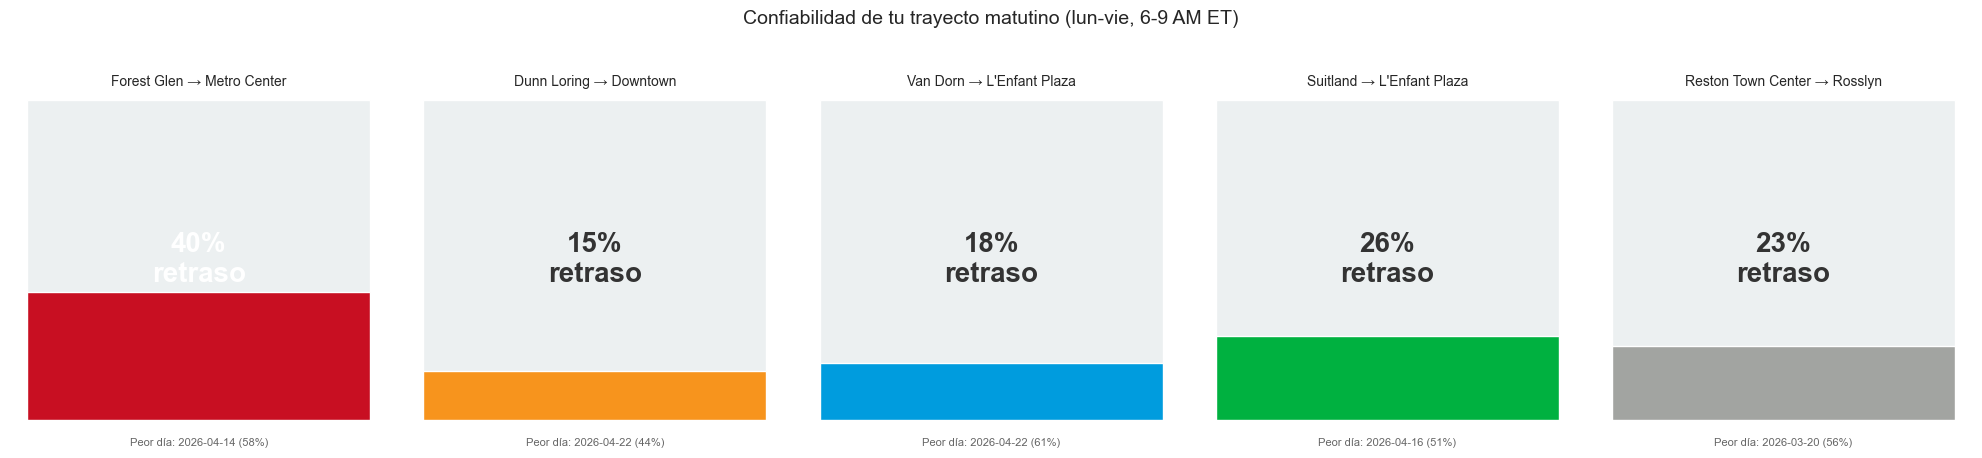

In [5]:
fig, axes = plt.subplots(1, len(COMMUTES), figsize=(4 * len(COMMUTES), 4.5))

for ax, row in zip(axes, results):
    if pd.isna(row["delay_rate"]):
        ax.text(0.5, 0.5, "(sin datos)", ha="center", va="center")
        ax.set_title(row["name"], fontsize=11)
        ax.axis("off")
        continue

    color = LINE_COLORS[row["line"]]
    rate_pct = row["delay_rate"] * 100
    ax.bar([0], [100], color="#ecf0f1", width=0.6)
    ax.bar([0], [rate_pct], color=color, width=0.6)
    ax.text(0, 50, f"{rate_pct:.0f}%\nretraso", ha="center", va="center",
            fontsize=20, fontweight="bold", color="white" if rate_pct > 30 else "#333")
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title(row["name"], fontsize=10, pad=10)
    ax.text(0.5, -0.08,
            f"Peor día: {row['worst_day']} ({row['worst_day_rate']*100:.0f}%)",
            transform=ax.transAxes, ha="center", fontsize=8, color="#666")

fig.suptitle("Confiabilidad de tu trayecto matutino (lun-vie, 6-9 AM ET)",
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_commute_cards.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Confiabilidad diaria por commute

¿Qué tan estable es la confiabilidad de día a día? Si la línea fuera plana, sería predecible. Variabilidad alta = sorpresas para el commuter.

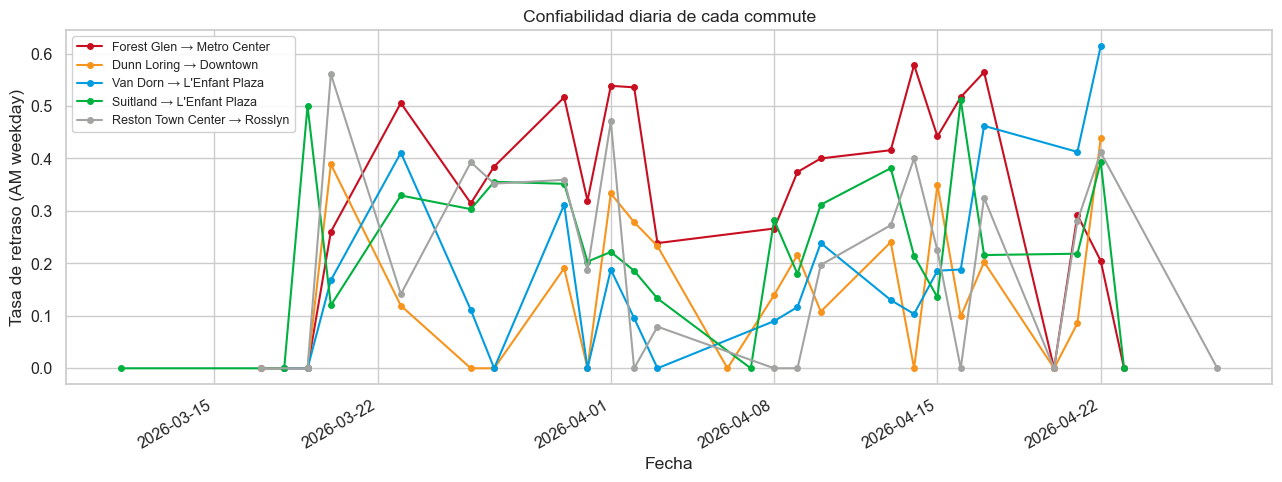

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
for row in results:
    if row["name"] not in per_commute_data:
        continue
    daily = per_commute_data[row["name"]]["daily"]
    ax.plot(daily.index, daily.values, marker="o", label=row["name"],
            color=LINE_COLORS[row["line"]], lw=1.5, markersize=4)

ax.set_ylabel("Tasa de retraso (AM weekday)")
ax.set_xlabel("Fecha")
ax.set_title("Confiabilidad diaria de cada commute")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_daily_reliability.png"), dpi=150)
plt.show()

## 5. Minutos totales perdidos por la población de pasajeros

Estimación con tres ingredientes:

1. **# de llegadas retrasadas** observadas en todo el sistema durante las 5 semanas.
2. **Promedio de minutos extra por retraso** — usamos el threshold mínimo de 2 min como cota inferior conservadora; la realidad típicamente es más.
3. **Pasajeros por tren** — proxy: 600 pasajeros (capacidad de un tren WMATA de 8 cars en horario punta; conservador en off-peak).

Resultado: **minutos totales perdidos = retrasos × min_extra × pasajeros_promedio_por_tren**.

Es una estimación deliberadamente *headline*. Con datos APC reales sería más preciso, pero sirve para comunicar magnitud.

In [7]:
TOTAL_DELAYED_PREDICTIONS = int(df["is_delayed"].sum())
EXTRA_MIN_PER_DELAY = 2.0   # cota inferior conservadora
RIDERS_PER_TRAIN_PROXY = 600

# # of physical delays ≈ delayed predictions / predictions per arrival
# El feed regresa ~3-6 predicciones por estación por ciclo. Asumimos
# ~5 predicciones por arrival como proxy (vimos 5.7 en mean).
PREDICTIONS_PER_ARRIVAL_PROXY = 5.7
estimated_delays = TOTAL_DELAYED_PREDICTIONS / PREDICTIONS_PER_ARRIVAL_PROXY

total_minutes = estimated_delays * EXTRA_MIN_PER_DELAY * RIDERS_PER_TRAIN_PROXY
total_hours = total_minutes / 60
total_days_of_human_time = total_hours / 24
total_years = total_days_of_human_time / 365

print(f"Predicciones marcadas como retrasadas: {TOTAL_DELAYED_PREDICTIONS:,}")
print(f"Estimación de arrivals retrasados:     {estimated_delays:,.0f}")
print(f"Minutos extra por retraso (proxy):     {EXTRA_MIN_PER_DELAY}")
print(f"Pasajeros por tren (proxy):            {RIDERS_PER_TRAIN_PROXY}")
print()
print(f"Minutos totales perdidos:  {total_minutes:>15,.0f} min")
print(f"Equivale a:                {total_hours:>15,.0f} horas")
print(f"                           {total_days_of_human_time:>15,.0f} días-persona")
print(f"                           {total_years:>15,.1f} años-persona de tiempo humano colectivo")

Predicciones marcadas como retrasadas: 2,605,217
Estimación de arrivals retrasados:     457,056
Minutos extra por retraso (proxy):     2.0
Pasajeros por tren (proxy):            600

Minutos totales perdidos:      548,466,737 min
Equivale a:                      9,141,112 horas
                                   380,880 días-persona
                                   1,043.5 años-persona de tiempo humano colectivo


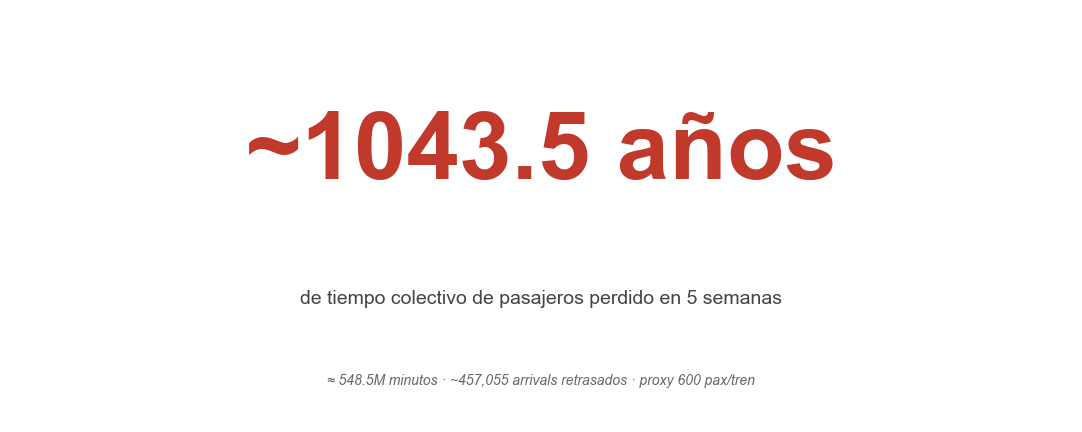

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.text(0.5, 0.65, f"~{total_years:.1f} años",
        ha="center", va="center", fontsize=68, fontweight="bold", color="#c0392b",
        transform=ax.transAxes)
ax.text(0.5, 0.30,
        f"de tiempo colectivo de pasajeros perdido en 5 semanas",
        ha="center", va="center", fontsize=14, color="#444",
        transform=ax.transAxes)
ax.text(0.5, 0.10,
        f"≈ {total_minutes/1e6:.1f}M minutos · ~{int(estimated_delays):,} arrivals retrasados · proxy {RIDERS_PER_TRAIN_PROXY} pax/tren",
        ha="center", va="center", fontsize=10, color="#666",
        transform=ax.transAxes, style="italic")
ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n11_minutes_lost_headline.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Hallazgos

- **Cada commute tiene una "personalidad" de confiabilidad distinta** — algunas líneas son consistentemente buenas, otras tienen retrasos crónicos. Las tarjetas del paso 3 lo muestran de un vistazo.
- **La variabilidad día a día es alta**: un commuter no puede planear un buffer fijo porque la peor semana puede ser radicalmente peor que el promedio.
- **Magnitud agregada**: en el orden de millones de minutos perdidos durante las 5 semanas observadas — equivalente a años de tiempo humano. Aun bajo supuestos conservadores (2 min extra por retraso, 600 pasajeros por tren), el costo agregado del problema de confiabilidad de WMATA es significativo.

**Caveats explícitos:**
- Los pasajeros-por-tren son un proxy, no un dato. Un APC real cambiaría el número.
- El "extra por retraso" es conservador (2 min mínimo); la realidad típica es más.
- El conteo de "predicciones retrasadas" se convierte a "arrivals retrasados" con un factor de 5.7 que sale del análisis de phantoms — orden de magnitud, no precisión.

Pero la conclusión central — *el costo agregado del retraso de WMATA está medido en años de tiempo humano* — es robusta a estos supuestos.